# 📊 Exploratory Data Analysis (EDA) – TAT Analytics

This section explores the dataset to understand:
- Data quality
- Distribution of tests
- TAT performance
- Operational bottlenecks

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (469129, 54)


,BookingCentre,ProcessingCentre,ActualTestCentre,InHouse/OutHouse,OutSource,OutSourceLab,PanelName,UHID,PName,Age,...,SRA-Registration(hrs),INOutTAT,ColorName,container,DoctorName,TagProcessingLab,LastStatus,ClientCode,InvoiceTo_ClientCode,SampleTypeName
0,HLM JEEVAN JYOTI HEALTH CARE AND RESEARCH CENTRE,HLM JEEVAN JYOTI HEALTH CARE AND RESEARCH CENTRE,NRL MUMBAI,InHouse,NaN,NaN,HLM JEEVAN JYOTI HEALTH CARE AND RESEARCH CENTRE,LDAA04220353,Mr.RANJAN PURKAYASTHA,47 Y 0 M 0 D,...,37:32:41,Out TAT,Black,NaN,SAMBUDDHA DHAR,HLM JEEVAN JYOTI HEALTH CARE AND RESEARCH CENTRE,Approved,HLM0054,HLM0054,TRACHEAL TUBE
1,SL NAGPUR,SL NAGPUR,NRL MUMBAI,InHouse,NaN,NaN,PUP KUNAL HOSPITAL,LDAA04249487,Ms.JUHI UIKEY,19 Y 0 M 0 D,...,15:01:53,In TAT,WHITE,LEAKPROOF CONTAINER,Natiq Parvez,SL NAGPUR,Approved,PUP1782,PUP1782,BAL
2,DL BEHRAMPORE,DL BEHRAMPORE,NRL MUMBAI,InHouse,NaN,NaN,DL BEHRAMPORE,LDAA04251179,Mr.NURJAMAN SK,15 Y 0 M 0 D,...,47:23:17,In TAT,WHITE,LEAKPROOF CONTAINER,MURSHIDABAD MEDICAL COLLEGE & HOSPITAL(OPD),DL BEHRAMPORE,Approved,DL0002,DL0002,BAL
3,COCO BARASAT,RRL KOLKATA,NRL MUMBAI,InHouse,NaN,NaN,COCO BARASAT,LDAA04256620,Mr.SUDHANSHU MAJUMDAR,54 Y 9 M 9 D,...,24:44:13,In TAT,WHITE,LEAKPROOF CONTAINER,S K Das,RRL KOLKATA,Approved,LMPCC0421,LMPCC0421,SPUTUM
4,RRL HYDERABAD,RRL HYDERABAD,NRL MUMBAI,InHouse,NaN,NaN,PUP LAXMI DIAGNOSTICS - JANGAON,LDAA04257351,Mrs.M RENUKA,35 Y 0 M 0 D,...,20:43:51,In TAT,PLAIN WHITE,PLASTIC BOX,SELF,RRL HYDERABAD,Approved,PUP6315,PUP6315,TISSUE


In [28]:
df.info()


<class 'pandas.DataFrame'>
Index: 469129 entries, 0 to 168611
Data columns (total 54 columns):
 #   Column                              Non-Null Count   Dtype          
---  ------                              --------------   -----          
 0   BookingCentre                       469129 non-null  str            
 1   ProcessingCentre                    469129 non-null  str            
 2   ActualTestCentre                    469129 non-null  str            
 3   InHouse/OutHouse                    469129 non-null  str            
 4   OutSource                           1613 non-null    str            
 5   OutSourceLab                        1613 non-null    str            
 6   PanelName                           469129 non-null  str            
 7   UHID                                469129 non-null  str            
 8   PName                               469129 non-null  str            
 9   Age                                 469129 non-null  str            
 10  Sex         

In [29]:
df.isnull().sum().sort_values(ascending=False)

OutSource                             467516
OutSourceLab                          467516
LogisticApp_Date                      466620
Last Transfer Date and Time           267248
BatchReceive_Date                     267248
container                             163514
ColorName                              55699
SampleTypeName                         18942
SRA-Approval(hrs)                      10348
ApprovedDateTime                        9486
ApprovedDate-Delivery(hrs)              9486
Collection-Approval(hrs)                9325
ResultEntry-Approval(hrs)               9325
ResultEnteredDateTime                   8311
DepartmentReceive-ResultEntry(hrs)      8267
DepartmentReceiveDateTime               7546
SRA-DepartmentReceive(hrs)              6790
SRAReceiveDateTime                      6617
Collection-SRA(hrs)                     6617
SRA-Registration(hrs)                   6617
Sex                                       34
DoctorName                                 9
SampleColl

## 🔍 Data Quality Insights
- Identified missing values in key columns such as outsourcing, transfer dates, and logistics dates
- These may impact TAT calculations

In [30]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [31]:
total_tests = df['SINNo'].nunique()

in_tat = df[df['INOutTAT'] == 'In TAT']['SINNo'].nunique()
out_tat = df[df['INOutTAT'] == 'Out TAT']['SINNo'].nunique()

percent_in_tat = (in_tat / total_tests) * 100

print("Total Tests:", total_tests)
print("In TAT:", in_tat)
print("Out TAT:", out_tat)
print("% In TAT:", round(percent_in_tat,2))

Total Tests: 296164
In TAT: 273339
Out TAT: 25699
% In TAT: 92.29


## 📌 KPI Insights
- Total test volume provides workload understanding  
- % In TAT reflects SLA compliance  
- Out TAT indicates operational inefficiency  

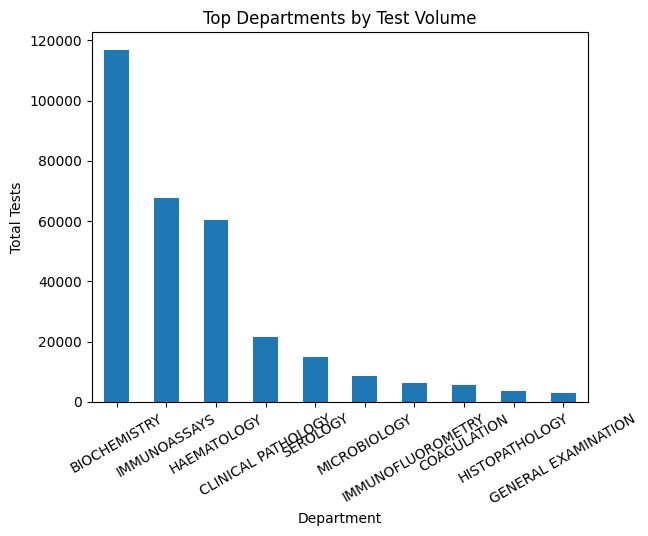

In [32]:
dept = df.groupby('DepartmentName')['SINNo'].nunique().sort_values(ascending=False)

dept.head(10).plot(kind='bar')

plt.title("Top Departments by Test Volume")
plt.xlabel("Department")
plt.ylabel("Total Tests")
plt.xticks(rotation=30)
plt.show()

## 🔍 Department Insights
- Certain departments handle higher test volumes  
- High volume may correlate with delays  

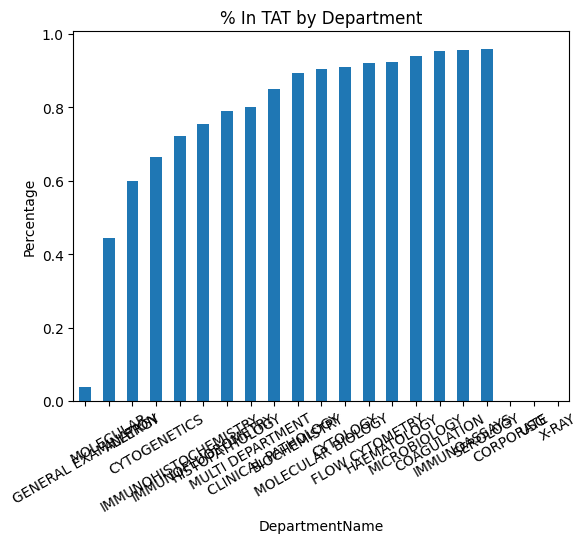

In [33]:
tat_dept = df.groupby('DepartmentName')['INOutTAT'].value_counts(normalize=True).unstack()

tat_dept['In TAT'].sort_values().plot(kind='bar')

plt.title("% In TAT by Department")
plt.ylabel("Percentage")
plt.xticks(rotation=30)
plt.show()

## ⚠️ TAT Insights by Department
- Departments with low % In TAT are bottlenecks  
- Requires operational improvement  

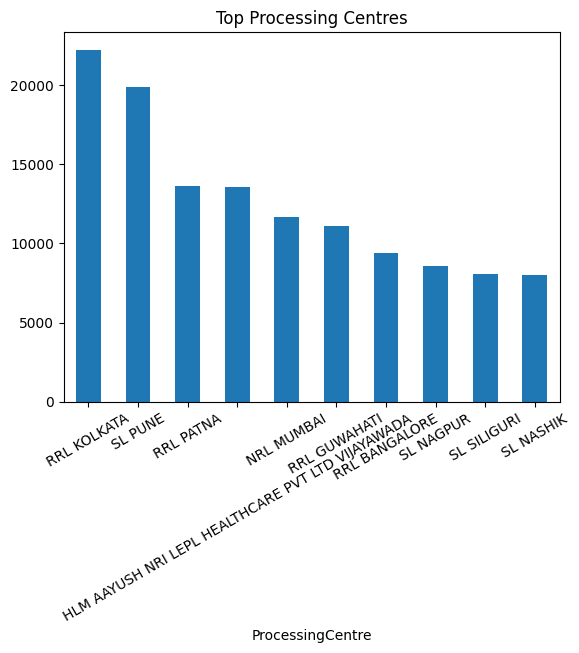

In [34]:
lab = df.groupby('ProcessingCentre')['SINNo'].nunique().sort_values(ascending=False)

lab.head(10).plot(kind='bar')

plt.title("Top Processing Centres")
plt.xticks(rotation=30)
plt.show()

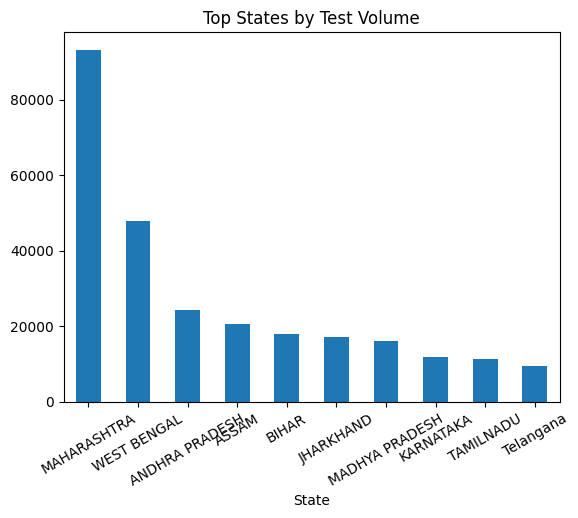

In [35]:
state = df.groupby('State')['SINNo'].nunique().sort_values(ascending=False)

state.head(10).plot(kind='bar')

plt.title("Top States by Test Volume")
plt.xticks(rotation=30)
plt.show()

## 🌍 Geography Insights
- Certain states dominate test volume  
- Regional performance differences may exist  

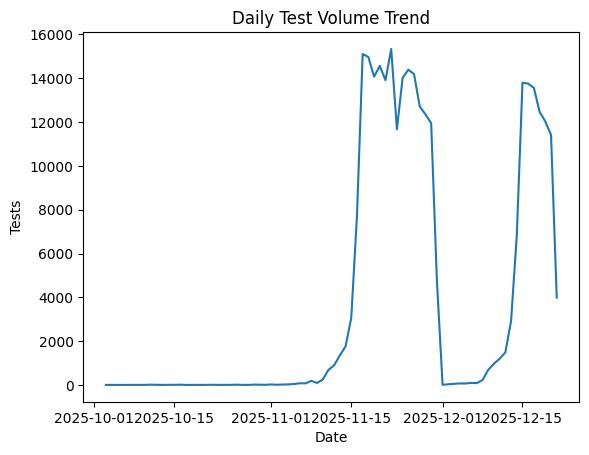

In [36]:
df['BookingDate'] = pd.to_datetime(df['BookingDate'], errors='coerce')

daily = df.groupby(df['BookingDate'].dt.date)['SINNo'].nunique()

daily.plot()

plt.title("Daily Test Volume Trend")
plt.xlabel("Date")
plt.ylabel("Tests")
plt.show()

## 📈 Time Trends
- Identifies peak workload days  
- Helps in resource planning  

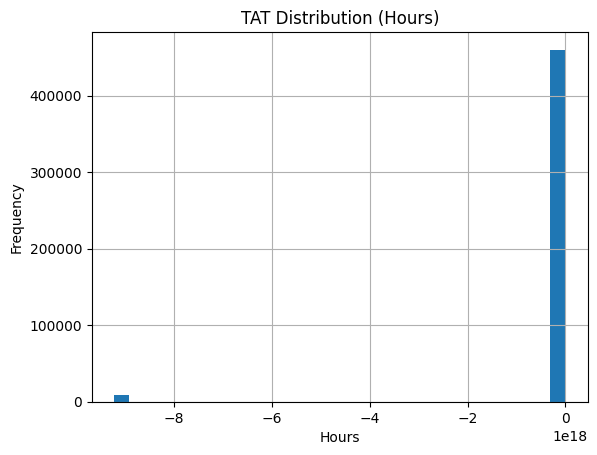

In [37]:
df['Booking-Approval(hrs)'] = pd.to_numeric(df['Booking-Approval(hrs)'], errors='coerce')

df['Booking-Approval(hrs)'].hist(bins=30)

plt.title("TAT Distribution (Hours)")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()

## ⏱️ TAT Distribution
- Shows spread of turnaround time  
- Helps identify extreme delays  

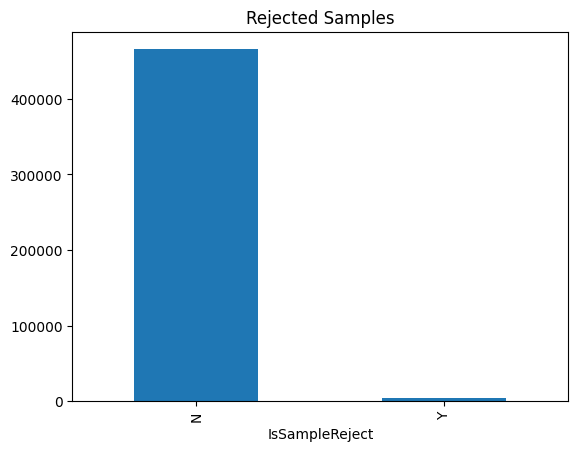

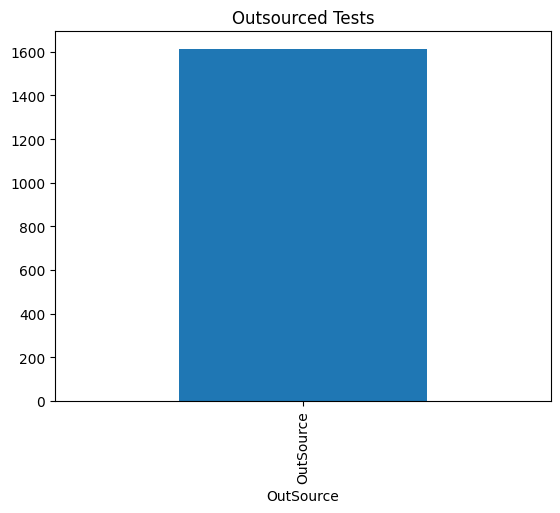

In [38]:
df['IsSampleReject'].value_counts().plot(kind='bar')
plt.title("Rejected Samples")
plt.show()

df['OutSource'].value_counts().plot(kind='bar')
plt.title("Outsourced Tests")
plt.show()

## ⚠️ Operational Impact
- Rejected and outsourced tests contribute to delays  
- Needs process optimization  

## 🔷 EDA Conclusion

- Identified key bottlenecks in departments and labs  
- Observed variation in TAT across regions  
- Found operational inefficiencies linked to rejection and outsourcing  
- Data-driven insights support improving SLA performance  